## 환경 확인 및 라이브러리 임포트

학습에 필요한 라이브러리가 잘 설치되어 있는지 버전을 확인합니다.

In [1]:
import torch
import numpy
import matplotlib

print("PyTorch:", torch.__version__)
print("NumPy:", numpy.__version__)
print("Matplotlib:", matplotlib.__version__)

# GPU 사용 가능 여부 확인 (중요!)
print("\nGPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))
    print("CUDA 버전:", torch.version.cuda)
else:
    print("⚠️ GPU를 인식하지 못합니다. CPU로 실행되며 매우 느립니다.")

PyTorch: 2.5.1+cu121
NumPy: 2.4.3
Matplotlib: 3.10.8

GPU 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 3070 Ti
CUDA 버전: 12.1


## 데이터 다운로드

**Korean-English Park 데이터셋**을 사용합니다.
한국어-영어 병렬 코퍼스(parallel corpus)로, 한국어와 그에 대응하는 영어 문장이 짝지어져 있어요.

- 출처: jungyeul/korean-parallel-corpora (GitHub)
- 형식: 한국어 파일(.ko)과 영어 파일(.en) 두 개

In [ ]:
import os
import urllib.request
import tarfile

# 작업 폴더 설정
WORK_DIR = r"C:\AI_study\Transforme"
data_dir = os.path.join(WORK_DIR, "data")
os.makedirs(data_dir, exist_ok=True)
print(f"📂 작업 폴더: {WORK_DIR}")
print(f"📂 데이터 폴더: {data_dir}")

# 파일 다운로드
url = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"
tar_gz_path = os.path.join(data_dir, "korean-english-park.train.tar.gz")

if not os.path.exists(tar_gz_path):
    print("⏬ 다운로드 시작...")
    urllib.request.urlretrieve(url, tar_gz_path)
    print(f"✅ 다운로드 완료: {tar_gz_path}")
else:
    print(f"✅ 이미 다운로드 완료된 파일: {tar_gz_path}")

# tar.gz 압축 해제 (Python으로 한 번에!)
print("\n📦 압축 해제 중...")
with tarfile.open(tar_gz_path, "r:gz") as tar:
    tar.extractall(path=data_dir)
print("✅ 압축 해제 완료!")

# 결과 확인
print("\n📋 데이터 폴더 내용:")
for f in sorted(os.listdir(data_dir)):
    file_path = os.path.join(data_dir, f)
    size_mb = os.path.getsize(file_path) / 1024 / 1024
    print(f"   - {f} ({size_mb:.2f} MB)")

다운로드된 데이터의 경로를 변수로 저장합니다.

In [2]:
import os

data_dir = r"C:\AI_study\Transforme\data"
kor_path = os.path.join(data_dir, "korean-english-park.train.ko")
eng_path = os.path.join(data_dir, "korean-english-park.train.en")

print(f"한국어 파일: {kor_path}")
print(f"영어 파일: {eng_path}")
print(f"한국어 파일 존재: {os.path.exists(kor_path)}")
print(f"영어 파일 존재: {os.path.exists(eng_path)}")

한국어 파일: C:\AI_study\Transforme\data\korean-english-park.train.ko
영어 파일: C:\AI_study\Transforme\data\korean-english-park.train.en
한국어 파일 존재: True
영어 파일 존재: True


## S데이터 정제 (Data Cleaning)

같은 문장이 여러 번 등장하는 **중복 데이터**를 제거합니다.

### 정제 과정
1. 한국어 / 영어 파일을 라인 단위로 읽기
2. 두 파일의 라인 수가 같은지 확인 (`assert`)
3. 한국어와 영어를 탭(`\t`)으로 연결해서 한 쌍으로 만듦
4. `set()`으로 중복 제거

In [3]:
# 데이터 정제 및 토큰화
def clean_corpus(kor_path, eng_path):
    # Windows에서는 encoding="utf-8" 명시 필수
    with open(kor_path, "r", encoding="utf-8") as f:
        kor = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f:
        eng = f.read().splitlines()
    assert len(kor) == len(eng)
    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))
    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)
print(f"중복 제거 후 문장 쌍 개수: {len(cleaned_corpus):,}개")

중복 제거 후 문장 쌍 개수: 78,968개


##  문장 전처리 함수

각 문장을 학습에 적합한 형태로 정제합니다.

### 전처리 과정
1. **소문자화**: 영어 문장 통일
2. **특수문자 제거**: 알파벳, 한글, `?.!,` 만 남기기
3. **구두점 분리**: `?`, `.`, `!`, `,` 앞뒤에 공백 → 별도 토큰으로 인식
4. **연속 공백 정리**: 여러 공백을 하나로

In [4]:
import re

def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    return sentence

# 테스트
test = "안녕하세요! 오늘 날씨가 좋네요."
print("원본:", test)
print("전처리:", preprocess_sentence(test))

원본: 안녕하세요! 오늘 날씨가 좋네요.
전처리: 안녕하세요 ! 오늘 날씨가 좋네요 . 


## SentencePiece 토크나이저 생성

**SentencePiece**는 Google이 만든 서브워드(subword) 토큰화 라이브러리입니다.

### 왜 SentencePiece?
- 형태소 분석기 없이도 한국어 처리 가능
- OOV(Out-Of-Vocabulary, 모르는 단어) 문제 완화
- 다양한 언어에 적용 가능

### 특수 토큰
- `pad_id=0`: 패딩 토큰 (길이 맞추기용)
- `bos_id=1`: Begin Of Sentence (문장 시작)
- `eos_id=2`: End Of Sentence (문장 끝)
- `unk_id=3`: Unknown (모르는 단어)

In [5]:
# SentencePiece를 활용하여 학습한 tokenizer를 생성합니다.
def generate_tokenizer(corpus,
                       vocab_size,
                       lang="ko",
                       pad_id=0,
                       bos_id=1,
                       eos_id=2,
                       unk_id=3):
    file = f"./{lang}_corpus.txt"
    model = f"{lang}_spm"
    
    # Windows용 utf-8 인코딩 명시
    with open(file, 'w', encoding='utf-8') as f:
        for row in corpus:
            f.write(str(row) + '\n')
    
    import sentencepiece as spm
    # 원본 코드의 버그 수정:
    # 1. --vocab_size=%d와 --pad_id 사이에 공백 추가
    # 2. --pad_id==%d (등호 두 개) → --pad_id=%d (등호 하나)
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size}'
        f' --pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )
    
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model}.model')
    return tokenizer

### 토크나이저 학습 실행

- 한국어/영어 어휘 크기: 각 8000개
- 한국어 / 영어 각각 토크나이저 학습
- 영어는 `bos`/`eos` 토큰 자동 추가 설정

⏰ **이 셀 실행은 5~20분 정도 걸릴 수 있어요.**

In [6]:
SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 8000   # 데이터 크기에 맞게 조정

eng_corpus = []
kor_corpus = []
for pair in cleaned_corpus:
    k, e = pair.split("\t")
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

print(f"전처리 완료: {len(kor_corpus):,}개 문장 쌍")
print(f"\n토크나이저 학습 시작... (5~20분 소요)")

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

print("✅ 토크나이저 학습 완료!")

전처리 완료: 78,968개 문장 쌍

토크나이저 학습 시작... (5~20분 소요)
✅ 토크나이저 학습 완료!


## 📊 토큰 빈도 분석 — 뉴스 데이터의 특성 확인

학습된 토크나이저가 데이터를 어떻게 서브워드로 분절했는지 확인합니다.

- 뉴스 도메인 특성상 반복되는 어휘 패턴이 존재
- 자주 등장하는 서브워드 Top 20 비교 (한국어 / 영어)
- 특정 토큰이 압도적으로 많다면 도메인 편향(domain bias)이 있다는 신호

C:\Users\yoehe\AppData\Local\Temp\ipykernel_10528\1280504363.py:45: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


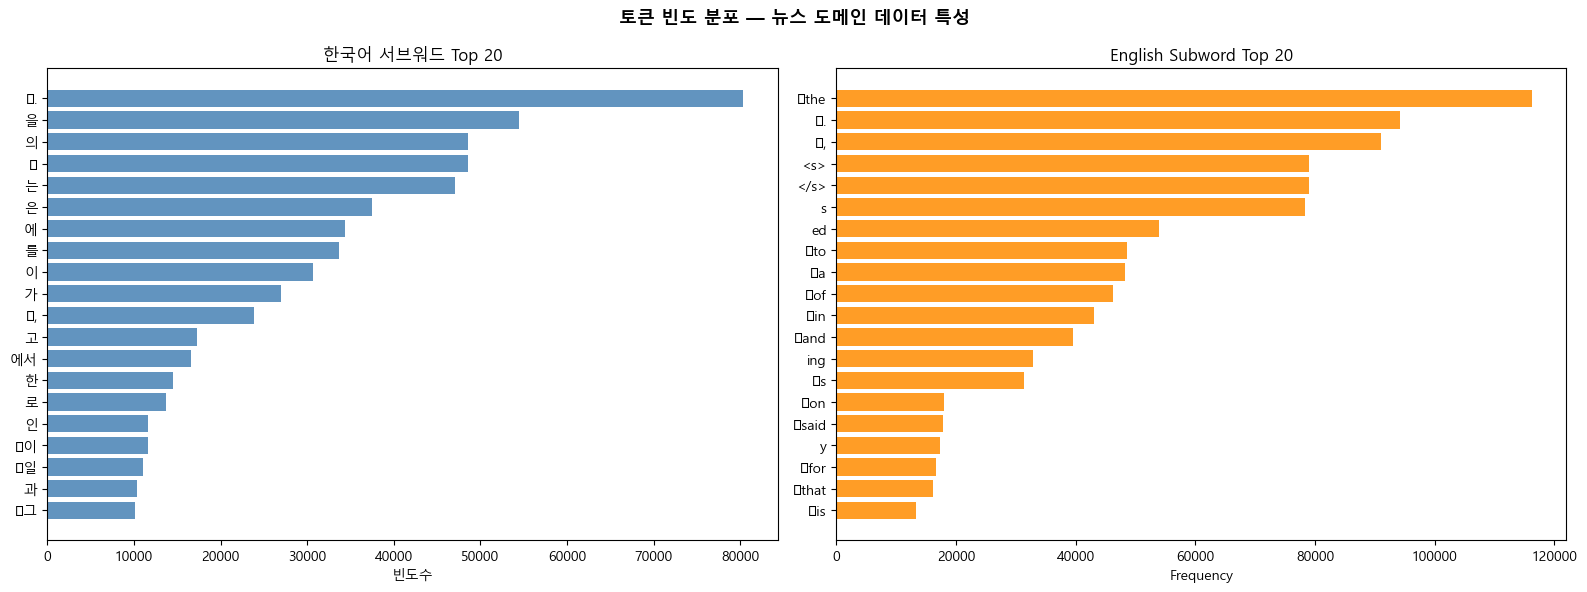

한국어 고유 서브워드 수: 8,488
영어  고유 서브워드 수: 7,995


In [7]:
import matplotlib.pyplot as plt
from collections import Counter

# Windows 한글 폰트 설정 (이후 모든 셀에 적용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 한국어 토큰 빈도 집계
ko_token_counter = Counter()
for sentence in kor_corpus:
    ko_token_counter.update(ko_tokenizer.encode_as_pieces(sentence))

# 영어 토큰 빈도 집계
en_token_counter = Counter()
for sentence in eng_corpus:
    en_token_counter.update(en_tokenizer.encode_as_pieces(sentence))

# Top 20 추출
ko_top20 = ko_token_counter.most_common(20)
en_top20 = en_token_counter.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 한국어 Top 20 가로 바 차트
ko_labels = [item[0] for item in ko_top20]
ko_counts = [item[1] for item in ko_top20]
axes[0].barh(range(len(ko_labels)), ko_counts, color='steelblue', alpha=0.85)
axes[0].set_yticks(range(len(ko_labels)))
axes[0].set_yticklabels(ko_labels, fontsize=10)
axes[0].set_xlabel('빈도수')
axes[0].set_title('한국어 서브워드 Top 20', fontsize=12)
axes[0].invert_yaxis()  # 가장 많은 것이 위로 오도록

# 영어 Top 20 가로 바 차트
en_labels = [item[0] for item in en_top20]
en_counts = [item[1] for item in en_top20]
axes[1].barh(range(len(en_labels)), en_counts, color='darkorange', alpha=0.85)
axes[1].set_yticks(range(len(en_labels)))
axes[1].set_yticklabels(en_labels, fontsize=10)
axes[1].set_xlabel('Frequency')
axes[1].set_title('English Subword Top 20', fontsize=12)
axes[1].invert_yaxis()

plt.suptitle('토큰 빈도 분포 — 뉴스 도메인 데이터 특성', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"한국어 고유 서브워드 수: {len(ko_token_counter):,}")
print(f"영어  고유 서브워드 수: {len(en_token_counter):,}")

##  학습 데이터 준비

### 작업 내용
1. 모든 문장을 **토큰 ID로 변환** (`encode_as_ids`)
2. **토큰 길이가 50 이하인 문장만** 학습 데이터로 사용
   - 너무 긴 문장은 메모리 부담 + 학습 어려움
3. PyTorch 텐서로 변환

길이 50 제한이 이번 트랜스포머의 `max_seq_len` 역할을 합니다.

In [8]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm

src_corpus = []
tgt_corpus = []
assert len(kor_corpus) == len(eng_corpus)

# 토큰의 길이가 50 이하인 문장만 남깁니다.
for idx in tqdm(range(len(kor_corpus)), desc="토큰화"):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])
    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

print(f"\n필터링 후 학습 데이터: {len(src_corpus):,}개")

토큰화:   0%|          | 0/78968 [00:00<?, ?it/s]


필터링 후 학습 데이터: 69,223개


### 패딩 (Padding)

배치 학습을 하려면 같은 배치 내 모든 문장의 길이가 같아야 합니다.
짧은 문장 뒤에 **0(pad_id)을 채워서** 길이를 맞춥니다.

```
원본:  [1, 5, 23, 4, 2]
패딩:  [1, 5, 23, 4, 2, 0, 0, 0, 0, 0]
```

In [9]:
def pad_sequences(sequences, padding_value=0):
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

# 패딩처리를 완료하여 학습용 데이터를 완성합니다.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)
print(f"Encoder 입력 shape: {enc_train.shape}")
print(f"Decoder 입력 shape: {dec_train.shape}")

Encoder 입력 shape: torch.Size([69223, 50])
Decoder 입력 shape: torch.Size([69223, 50])


## 📊 데이터 길이 분포 — max_seq_len=50을 선택한 이유

필터링 전 전체 데이터의 토큰 길이 분포를 히스토그램으로 시각화합니다.

- **빨간 수직선** = `max_seq_len` 기준 (이 선 오른쪽 문장은 제외됨)
- 분포의 꼬리(tail)가 어디서 시작하는지 보면 적절한 기준을 알 수 있음
- 너무 짧게 자르면 **데이터 손실**, 너무 길게 자르면 **메모리 부담**
- 대부분의 문장이 기준선 왼쪽에 몰려 있다면 잘 선택된 기준

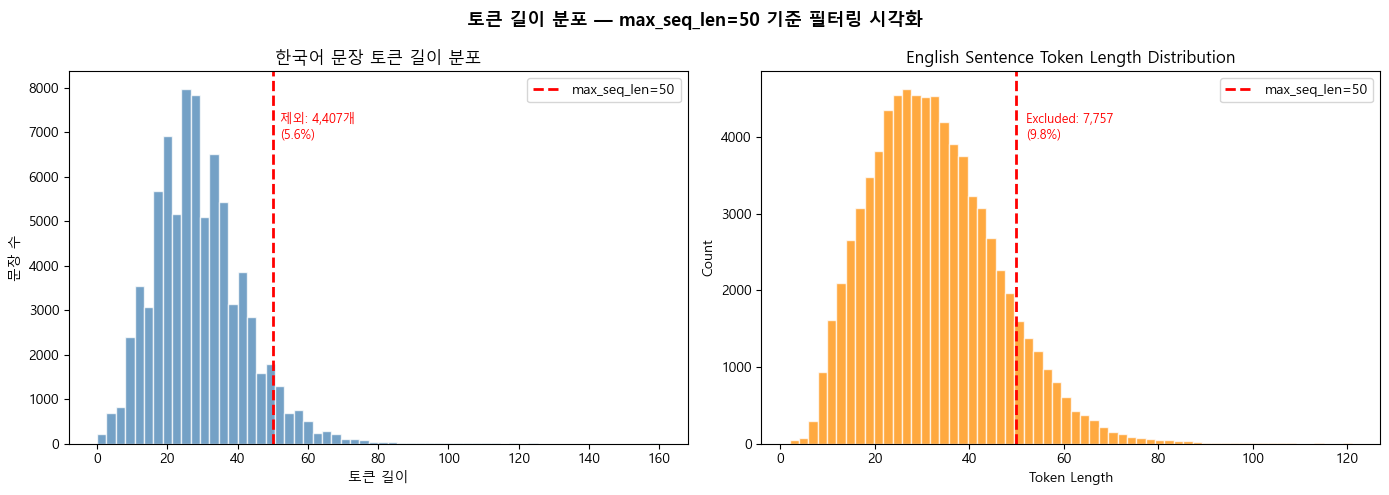

전체 문장 쌍: 78,968개
필터 후 (≤50): 69,223개 (87.7% 보존)


In [10]:
import matplotlib.pyplot as plt

MAX_SEQ_LEN = 50  # 현재 코드의 필터 기준값

# 전체 코퍼스의 토큰 길이 계산 (필터링 전 원본)
ko_lengths = [len(ko_tokenizer.encode_as_ids(s)) for s in kor_corpus]
en_lengths = [len(en_tokenizer.encode_as_ids(s)) for s in eng_corpus]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 한국어 길이 분포 히스토그램
axes[0].hist(ko_lengths, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].axvline(x=MAX_SEQ_LEN, color='red', linewidth=2, linestyle='--',
                label=f'max_seq_len={MAX_SEQ_LEN}')
axes[0].set_xlabel('토큰 길이')
axes[0].set_ylabel('문장 수')
axes[0].set_title('한국어 문장 토큰 길이 분포')
axes[0].legend()
# 기준선 초과 비율 텍스트 표시
ko_exceed = sum(1 for l in ko_lengths if l > MAX_SEQ_LEN)
axes[0].text(MAX_SEQ_LEN + 2, axes[0].get_ylim()[1] * 0.82,
             f'제외: {ko_exceed:,}개\n({ko_exceed/len(ko_lengths)*100:.1f}%)',
             color='red', fontsize=9)

# 영어 길이 분포 히스토그램
axes[1].hist(en_lengths, bins=60, color='darkorange', alpha=0.75, edgecolor='white')
axes[1].axvline(x=MAX_SEQ_LEN, color='red', linewidth=2, linestyle='--',
                label=f'max_seq_len={MAX_SEQ_LEN}')
axes[1].set_xlabel('Token Length')
axes[1].set_ylabel('Count')
axes[1].set_title('English Sentence Token Length Distribution')
axes[1].legend()
# 기준선 초과 비율 텍스트 표시
en_exceed = sum(1 for l in en_lengths if l > MAX_SEQ_LEN)
axes[1].text(MAX_SEQ_LEN + 2, axes[1].get_ylim()[1] * 0.82,
             f'Excluded: {en_exceed:,}\n({en_exceed/len(en_lengths)*100:.1f}%)',
             color='red', fontsize=9)

plt.suptitle(f'토큰 길이 분포 — max_seq_len={MAX_SEQ_LEN} 기준 필터링 시각화',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"전체 문장 쌍: {len(ko_lengths):,}개")
print(f"필터 후 (≤{MAX_SEQ_LEN}): {len(src_corpus):,}개 ({len(src_corpus)/len(ko_lengths)*100:.1f}% 보존)")

##  Positional Encoding 함수

**문장의 순서 정보를 모델에 전달**하기 위한 함수입니다.

### 수식
```
PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
```

- 짝수 차원: `sin`
- 홀수 차원: `cos`
- 각 위치마다 **고유한 패턴** 생성

---
### 🔍 이론 보강: 좋은 Positional Encoding의 4가지 조건
1. **고유성**: 각 위치(pos)마다 고유한 인코딩 값 → 서로 다른 위치가 같은 패턴을 가지면 안 됨
2. **일정한 거리**: 어떤 두 위치의 거리도 시퀀스 길이와 관계없이 일정해야 함
3. **일반화**: 학습 때 보지 못한 더 긴 시퀀스에도 자연스럽게 적용 가능해야 함
4. **재현성**: 결정론적(deterministic) — 랜덤성 없이 항상 같은 값 생성

### Sinusoidal PE vs Learnable Positional Embedding

| 구분 | Sinusoidal PE (이 코드) | Learnable PE (BERT) |
|---|---|---|
| 학습 여부 | ❌ 고정값 | ✅ 학습 파라미터 |
| 긴 시퀀스 일반화 | ✅ 가능 | ❌ 학습 범위 내만 |
| 특징 | 수식으로 결정 | 데이터에서 학습 |

- 트랜스포머 원논문(Vaswani et al. 2017)은 Sinusoidal PE 사용
- BERT, GPT 등 후속 모델들은 대부분 Learnable PE로 전환

In [11]:
import numpy as np

def positional_encoding(pos, d_model):
    # 각 단어 위치마다 고유한 "주민등록번호"를 부여하는 함수
    # pos: 시퀀스 최대 길이, d_model: 임베딩 차원 수
    def cal_angle(position, i):
        # sin/cos 안에 들어갈 각도(라디안)를 계산
        # 분모 10000^(i/d_model)이 커질수록 주기가 길어짐 → 차원마다 다른 주파수
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        # 한 위치에 대해 d_model개 차원의 각도값 리스트 반환
        return [cal_angle(position, i) for i in range(d_model)]

    # 모든 위치(0~pos-1)에 대한 각도 행렬: shape = (pos, d_model)
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    # 짝수 차원(2i)에 sin 적용 (0::2 → 인덱스 0, 2, 4, ...)
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    # 홀수 차원(2i+1)에 cos 적용 (1::2 → 인덱스 1, 3, 5, ...)
    # 짝수/홀수를 다르게 쓰는 이유: 인접 차원이 서로 보완하여 상대 위치 파악에 유리
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    # ⭐ 핵심 수정: NumPy → PyTorch Tensor로 변환
    # PyTorch는 NumPy 배열에 .unsqueeze() 같은 Tensor 메서드를 직접 쓸 수 없으므로 변환 필요
    return torch.tensor(sinusoid_table, dtype=torch.float32)

## 📊 Positional Encoding 시각화 — 각 위치가 고유한 인코딩을 갖는다는 것 확인

PE 행렬을 히트맵으로 보면 **각 위치(행)마다 서로 다른 컬러 패턴** 이 보입니다.

- **가로축**: 임베딩 차원 (0 ~ d_model-1)
- **세로축**: 위치 (0 ~ pos-1)
- **낮은 차원**: 빠른 주기(짧은 파장) — 인접 위치를 세밀하게 구분
- **높은 차원**: 느린 주기(긴 파장) — 멀리 떨어진 위치를 넓게 구분
- 두 종류의 주기를 조합하면 모든 위치를 고유하게 표현 가능 (이진수 원리와 유사)

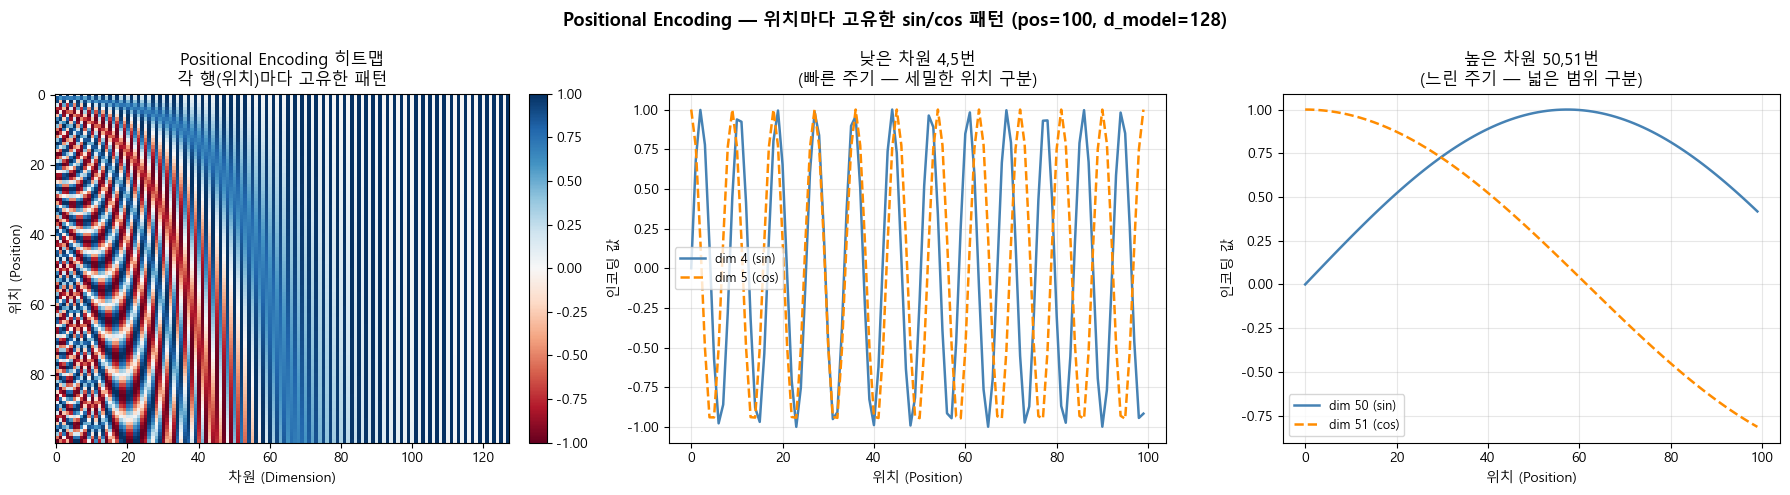

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 시각화 전용 PE 생성 (실제 모델 학습과 무관)
pos_vis = 100    # 시각화할 위치 수
d_vis   = 128    # 시각화할 차원 수
pe_matrix = positional_encoding(pos_vis, d_vis).numpy()  # shape: (100, 128)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# [왼쪽] PE 전체 히트맵
im = axes[0].imshow(pe_matrix, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xlabel('차원 (Dimension)')
axes[0].set_ylabel('위치 (Position)')
axes[0].set_title('Positional Encoding 히트맵\n각 행(위치)마다 고유한 패턴')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# [가운데] 낮은 차원 (4, 5번째) — 빠른 주기
dim_low = 4
axes[1].plot(pe_matrix[:, dim_low],     color='steelblue',  linewidth=1.8,
             label=f'dim {dim_low} (sin)')
axes[1].plot(pe_matrix[:, dim_low + 1], color='darkorange', linewidth=1.8,
             linestyle='--', label=f'dim {dim_low+1} (cos)')
axes[1].set_xlabel('위치 (Position)')
axes[1].set_ylabel('인코딩 값')
axes[1].set_title(f'낮은 차원 {dim_low},{dim_low+1}번\n(빠른 주기 — 세밀한 위치 구분)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# [오른쪽] 높은 차원 (50, 51번째) — 느린 주기
dim_high = 50
axes[2].plot(pe_matrix[:, dim_high],     color='steelblue',  linewidth=1.8,
             label=f'dim {dim_high} (sin)')
axes[2].plot(pe_matrix[:, dim_high + 1], color='darkorange', linewidth=1.8,
             linestyle='--', label=f'dim {dim_high+1} (cos)')
axes[2].set_xlabel('위치 (Position)')
axes[2].set_ylabel('인코딩 값')
axes[2].set_title(f'높은 차원 {dim_high},{dim_high+1}번\n(느린 주기 — 넓은 범위 구분)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle('Positional Encoding — 위치마다 고유한 sin/cos 패턴 (pos=100, d_model=128)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##  Multi-Head Attention 모듈

**트랜스포머의 핵심 모듈**

### 구성
- `W_q, W_k, W_v`: Q, K, V를 만드는 Linear 레이어
- `scaled_dot_product_attention`: 어텐션 점수 계산 + Softmax
- `split_heads` / `combine_heads`: 헤드 분할/결합
- `linear`: 최종 출력 Linear

### 흐름
```
1. W_q, W_k, W_v로 Q, K, V 생성
2. 헤드 개수만큼 분할 (예: 8개)
3. 각 헤드에서 Scaled Dot-Product Attention
4. 결과를 다시 합침
5. 최종 Linear 통과
```

---
### 🔍 이론 보강: Q/K/V의 기원

Q/K/V는 **Bahdanau Attention (2015)**에서 진화한 개념입니다.

- Bahdanau: 디코더 은닉 상태 s_i (Query 역할) + 인코더 은닉 상태 h_j (Key/Value 역할)
- 트랜스포머: 이를 명시적으로 분리하여 Q, K, V 세 개의 별도 행렬로 투영

### Scaling (÷√d_k)의 필요성
- d_k가 크면 내적(dot product) 값이 매우 커짐
- 큰 값이 Softmax에 들어가면 기울기(gradient)가 극도로 작아짐 (softmax saturation)
- √d_k로 나누어 분산을 1로 정규화 → 안정적인 gradient 흐름 유지

### Causality Masking과 자기회귀(Autoregressive) 특성
- 디코더는 예측 시 **미래 토큰을 볼 수 없어야** 함 (시험에서 답을 미리 보는 것과 같으므로)
- Causality Mask: 현재 위치 이후의 토큰에 -1e9를 더해 Softmax 후 ≈0으로 만듦
- 이렇게 하면 디코더가 왼쪽(과거)만 보고 다음 토큰을 예측하는 **자기회귀 특성** 유지

In [13]:
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        # W_q: Q(Query) 생성 — 도서관 비유: "찾는 것 (검색어)"
        self.W_q = nn.Linear(d_model, d_model)
        # W_k: K(Key) 생성 — 도서관 비유: "있는 것 (책 제목)"
        self.W_k = nn.Linear(d_model, d_model)
        # W_v: V(Value) 생성 — 도서관 비유: "실제 내용 (책 내용)"
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = K.shape[-1]
        # Step 1: Q와 K의 내적으로 유사도(어텐션 점수) 계산 — shape: (batch, heads, seq, seq)
        QK = torch.matmul(Q, K.transpose(-2, -1))
        # Step 2: sqrt(d_k)로 나누기 — d_k가 커질수록 내적 값이 커져 Softmax 기울기 소실 방지
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
        # Step 3: 마스크 적용 — mask==1인 위치를 -1e9로 채워 Softmax 후 거의 0이 되게 함
        if mask is not None:
            scaled_qk = scaled_qk.masked_fill(mask == 1, float('-1e9'))
        # Step 4: Softmax로 확률 변환 — 각 행의 합이 1이 되어 가중치처럼 작동
        attentions = F.softmax(scaled_qk, dim=-1)
        # Step 5: V와 가중합 — "어디를 얼마나 볼지" 결정된 가중치로 실제 내용을 조합
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        # [batch, seq, d_model] → [batch, num_heads, seq, depth]로 분할
        # 비유: 512차원 "바나나"를 노란색/단맛/형태 등 num_heads개 시각으로 분리
        bsz, seq_len, d_model = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        # [batch, num_heads, seq, depth] → [batch, seq, d_model]로 다시 합침
        bsz, num_heads, seq_len, depth = x.shape
        # contiguous(): permute 후 메모리가 비연속적으로 되어 view() 실패할 수 있으므로 재배치 필수
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights

##  Position-wise Feed-Forward Network (FFN)

각 단어 위치마다 **독립적으로 적용**되는 신경망입니다.

### 구조
```
입력 [d_model] → Linear → ReLU → Linear → 출력 [d_model]
                 (d_ff)
```

- 차원을 4배 확장 후 다시 축소: 512 → 2048 → 512
- 비선형성 + 표현력 강화

In [14]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        # fc1: 차원 확장 (d_model → d_ff, 보통 4배) — 표현력을 일시적으로 크게 늘림
        self.fc1 = nn.Linear(d_model, d_ff)
        # fc2: 차원 축소 (d_ff → d_model) — 다시 원래 차원으로 압축
        self.fc2 = nn.Linear(d_ff, d_model)
        # ReLU: 비선형성 추가 — 선형 변환만으로는 표현할 수 없는 패턴을 학습 가능하게 함
        self.relu = nn.ReLU()

    def forward(self, x):
        # "Position-wise" = 각 단어 위치마다 독립적으로 동일한 가중치 적용
        # 행렬 곱 구조상 [batch, seq, d_model] × [d_model, d_ff]는 자동으로 위치별 독립 연산
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

##  Encoder Layer

Encoder Block 하나를 구현합니다.

### 구조 (2개 서브레이어)
1. **Multi-Head Self-Attention** + Residual + LayerNorm
2. **Position-wise FFN** + Residual + LayerNorm

### 패턴 (Pre-LayerNorm 방식)
```
residual = x
out = LayerNorm(x)
out = SubLayer(out)
out = Dropout(out)
out += residual
```

각 서브레이어에 **잔차 연결(Residual)** 적용!

---
### 🔍 이론 보강: Residual Connection

**수식**: `y = F(x) + x`  (출력 = 서브레이어 출력 + 입력)

- **기원**: ResNet (He et al., 2015) — "깊은 네트워크는 학습이 잘 안 된다"는 문제를 해결
- **핵심 원리 ("못해도 본전")**: 서브레이어 F(x)가 아무것도 학습 못해도 x(입력)는 그대로 전달
  - 최악의 경우: F(x) = 0이면 y = x (항등함수) — 네트워크가 망가지지 않음
  - gradient 소실 문제 완화: 역전파 시 residual 경로를 통해 gradient가 직접 흐름

### 🔍 이론 보강: Layer Normalization
- **정규화 대상**: 배치(샘플) 차원이 아니라 **Feature(특성) 차원**을 정규화
- **Batch Normalization과 차이**:
  - BatchNorm: 배치 내 같은 특성끼리 정규화 → 배치 크기에 민감, 시퀀스 길이가 다르면 불안정
  - LayerNorm: 한 샘플 내 모든 특성을 정규화 → 배치 크기와 무관, RNN/Transformer에 적합
- eps=1e-6: 분모가 0이 되는 것을 방지하는 작은 상수

In [15]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # ── 서브레이어 1: Multi-Head Self-Attention ──
        # Pre-LayerNorm 패턴: residual 저장 → LayerNorm → SubLayer → Dropout → residual 더하기
        # 이 순서가 gradient 흐름을 안정화시켜 깊은 네트워크 학습을 가능하게 함
        # Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        # ── 서브레이어 2: Position-wise FFN ──
        # 동일한 Pre-LayerNorm 패턴 반복 적용
        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

##  Decoder Layer

Decoder Block 하나를 구현합니다.

### 구조 (3개 서브레이어) — Encoder보다 한 층 더!
1. **Masked Multi-Head Self-Attention** + Residual + LayerNorm
2. **Cross-Attention (Encoder-Decoder Attention)** + Residual + LayerNorm
3. **Position-wise FFN** + Residual + LayerNorm

### Cross-Attention의 특징
- Q는 Decoder에서, K와 V는 Encoder에서 옴
- "Encoder가 만든 정보 중 지금 어디를 봐야 할까?" 를 결정

---
### 🔍 이론 보강: Encoder vs Decoder 차이 요약

| 구분 | Encoder | Decoder |
|---|---|---|
| 서브레이어 수 | 2개 | 3개 |
| Self-Attention | 양방향 (모든 토큰을 봄) | 단방향 (Masked, 과거만 봄) |
| Cross-Attention | ❌ 없음 | ✅ 있음 (Q: 디코더, K/V: 인코더) |
| 목적 | 입력 문장 표현 학습 | 출력 토큰 순차 생성 |

### Residual Connection과 Layer Normalization
- Encoder와 동일한 Pre-LayerNorm 패턴 적용 (설명은 Encoder Layer 셀 참조)
- 3개의 서브레이어 각각에 독립적으로 Residual + LayerNorm 적용
- norm_1, norm_2, norm_3: 각 서브레이어마다 별도의 LayerNorm 파라미터 보유

In [16]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        # ── 서브레이어 1: Masked Self-Attention (디코더 내부) ──
        # Q/K/V 모두 디코더 입력(x)에서 옴 — 지금까지 생성된 토큰끼리 서로 봄
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        # ── 서브레이어 2: Cross-Attention (인코더-디코더 연결) ──
        # Encoder와 다른 핵심 부분: Q는 디코더에서, K/V는 인코더 출력(enc_out)에서 옴
        # "인코더가 만든 정보 중 지금 어디를 봐야 할까?"를 결정
        # Multi-Head Attention (Cross-Attention)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        # ── 서브레이어 3: Position-wise FFN ──
        # Encoder와 동일한 구조 (Encoder보다 총 3개 서브레이어)
        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

##  Encoder / Decoder 스택

Encoder Layer / Decoder Layer를 **N개 쌓아서** 전체 인코더/디코더를 구성합니다.

논문에서는 N=6이지만, 메모리 부담을 줄이기 위해 **N=2**로 시작합니다.

In [17]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        # nn.ModuleList: 여러 레이어를 리스트처럼 관리하면서 PyTorch가 파라미터를 자동 인식하게 함
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            # 각 레이어의 어텐션 가중치를 저장 — 나중에 시각화(어디를 봤는지 히트맵)에 사용
            enc_attns.append(enc_attn)
        return out, enc_attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        # nn.ModuleList로 n_layers개의 DecoderLayer를 쌓음 (논문은 6층, 여기서는 2층)
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, causality_mask, padding_mask
            )
            # Self-Attention과 Cross-Attention 가중치를 각각 저장 — 레이어별 시각화용
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

## 전체 Transformer 모델

지금까지 만든 모든 구성요소를 합쳐 **완전한 Transformer**를 만듭니다.

### 구성요소
- `enc_emb`, `dec_emb`: 소스/타겟 임베딩 레이어
- `pos_encoding`: Positional Encoding 테이블
- `encoder`, `decoder`: 인코더/디코더 스택
- `fc`: 출력층 (타겟 어휘 크기로 매핑)

### Weight Sharing
`shared=True`일 때 출력층(`fc`)과 디코더 임베딩(`dec_emb`)의 가중치를 공유합니다.
- 메모리 절약
- 학습 안정성 향상

### √d_model 스케일링
임베딩 값에 `√d_model`을 곱하는 이유:
- Positional Encoding과 분포 맞추기
- PE가 임베딩을 압도하지 않도록 방지

In [18]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.shared = shared
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        # ⭐ 핵심 수정: register_buffer로 등록 → GPU 자동 이동 + 학습 안 됨
        # register_buffer: 학습은 되지 않지만 모델의 일부로서 .to(device) 시 GPU로 자동 이동
        self.register_buffer('pos_encoding', positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        # shared=True: 디코더 임베딩(dec_emb)과 출력 Linear(fc)가 가중치 공유
        # 메모리 절약 + 입력 임베딩과 출력 표현이 같은 공간에 있어 학습 안정성 향상
        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.shape[1]
        out = emb(x)
        if self.shared:
            # sqrt(d_model) 곱하는 이유: Weight Sharing 시 임베딩과 출력 Linear의 분포 균형을 맞추고
            # Positional Encoding의 값이 임베딩을 압도하지 않도록 스케일 조정
            out *= torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))
        # buffer로 등록했으니 이미 같은 device에 있음
        pos_enc = self.pos_encoding[:seq_len, :].unsqueeze(0)
        out += pos_enc
        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)
        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in, enc_out, causality_mask, dec_mask)
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

## 마스크 생성 함수

트랜스포머에 필요한 두 종류의 마스크를 만듭니다.

### ① Padding Mask
- 패딩 토큰(0)을 어텐션에서 무시하기 위함
- 패딩 위치 = 1, 실제 토큰 위치 = 0

### ② Causality Mask (인과 마스크)
- 디코더가 **미래 토큰을 보지 못하게** 하기 위함
- 자기회귀(autoregressive) 특성 유지
- 대각항 제외 삼각 행렬 모양

### 두 마스크 합치기
`torch.max(padding_mask, causality_mask)` — 둘 중 하나라도 1이면 가림

---
### 🔍 이론 보강: Causality Mask 상세

**자기회귀(Autoregressive) 특성**: 디코더가 t번째 토큰을 예측할 때 1 ~ t-1번째까지만 참조해야 함

```
위치: 1  2  3  4  5
1  [ 0  1  1  1  1 ]  ← 1번 위치는 자신만 볼 수 있음
2  [ 0  0  1  1  1 ]  ← 2번 위치는 1,2번만 볼 수 있음
3  [ 0  0  0  1  1 ]
4  [ 0  0  0  0  1 ]
5  [ 0  0  0  0  0 ]  ← 5번 위치는 모두 볼 수 있음
```
(1: 가림, 0: 허용)

**대각항(현재 위치 자신)을 포함하지 않는 이유**:
- 자기 자신은 반드시 볼 수 있어야 Softmax 입력에 유효한 값이 존재
- 대각항까지 모두 -1e9로 채우면 해당 행의 Softmax 입력이 전부 -1e9가 되어 NaN 발생 가능

**-1e9 트릭**: Softmax(x) = exp(x) / Σexp(x) 에서 exp(-1e9) ≈ 0 이므로 마스크된 위치는 사실상 0

In [19]:
def generate_padding_mask(seq):
    # 패딩된 부분(0)을 1로 변환하여 마스크 생성 — 1인 위치는 어텐션에서 가려야 할 곳
    mask = (seq == 0).float()
    # None으로 차원 확장: [batch, seq] → [batch, 1, 1, seq] (헤드/쿼리 차원에 브로드캐스팅)
    return mask[:, None, None, :]

def generate_causality_mask(src_len, tgt_len):
    # 미래 정보를 참조하지 않도록 Causal Mask 생성
    # torch.eye + cumsum 트릭으로 하삼각 행렬 생성 (대각 포함 아래는 0, 위는 1)
    # 대각항을 포함하지 않는 이유: 현재 위치 자신은 볼 수 있어야 하며,
    # 대각항도 1로 막으면 Softmax 입력이 전부 -1e9가 돼 NaN 발생 가능
    mask = 1 - torch.cumsum(torch.eye(src_len, tgt_len), dim=0)
    return mask.float()

def generate_masks(src, tgt):
    # Encoder-Decoder에서 사용할 마스크 생성
    enc_mask = generate_padding_mask(src)
    dec_mask = generate_padding_mask(tgt)
    dec_causality_mask = generate_causality_mask(tgt.shape[1], tgt.shape[1])
    # torch.max로 두 마스크를 합침: 패딩이거나 미래 위치면 둘 중 하나라도 1이면 가려야 함
    dec_mask = torch.max(dec_mask, dec_causality_mask.to(dec_mask.device))
    dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])
    dec_enc_mask = torch.max(enc_mask, dec_enc_causality_mask.to(enc_mask.device))
    return enc_mask, dec_enc_mask, dec_mask

## 📊 마스크 시각화 — 두 마스크의 차이와 합치는 이유

가짜 시퀀스(실제 토큰 7개 + PAD 3개)로 각 마스크를 직접 눈으로 확인합니다.

| 마스크 | 가리는 대상 | 필요한 이유 |
|---|---|---|
| Padding Mask | PAD(0) 위치 | 패딩은 의미 없으므로 어텐션에서 무시 |
| Causality Mask | 미래 위치 (삼각형 위쪽) | 자기회귀 특성 유지 |
| Decoder Mask (합산) | 둘 중 하나라도 해당 | OR 연산으로 통합 |

**노란색/밝은색 = 1 (차단)**, **파란색/어두운색 = 0 (허용)**

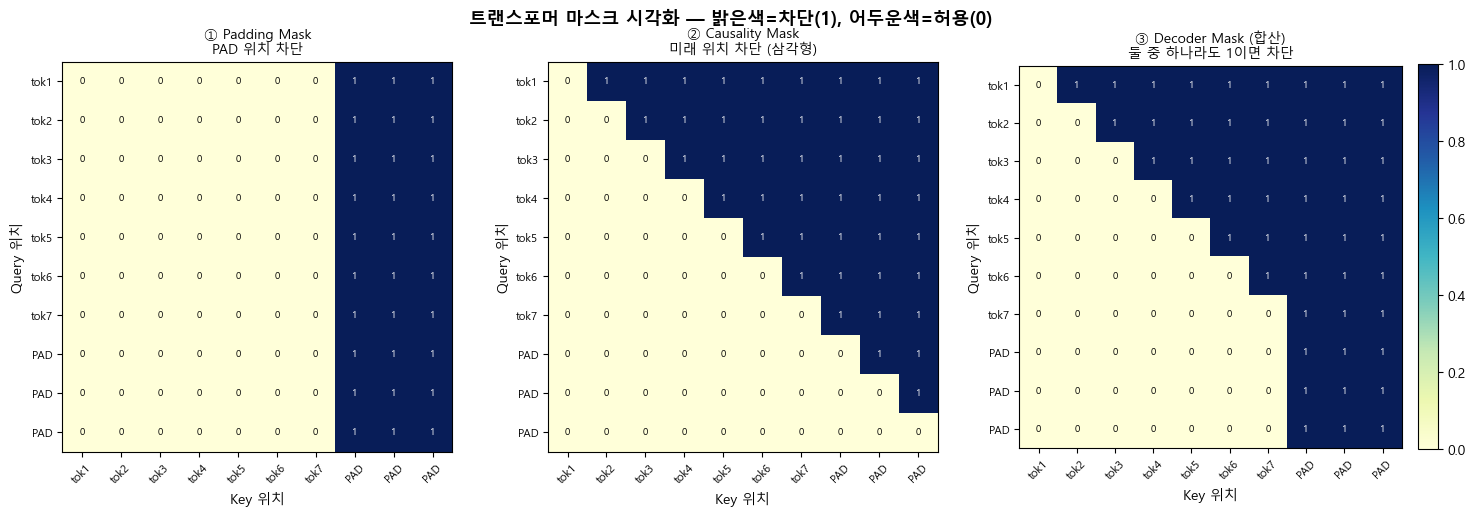

In [20]:
import matplotlib.pyplot as plt
import torch

# 가짜 시퀀스 생성: 실제 토큰 7개 + PAD(0) 3개
fake_tgt = torch.tensor([[5, 12, 8, 3, 17, 22, 9, 0, 0, 0]])
seq_len = fake_tgt.shape[1]

# 각 마스크 생성
pad_mask  = generate_padding_mask(fake_tgt)               # (1, 1, 1, 10)
caus_mask = generate_causality_mask(seq_len, seq_len)      # (10, 10)

# Decoder 합성 마스크 (OR 연산)
dec_combined = torch.max(pad_mask,
                         caus_mask.unsqueeze(0).unsqueeze(0))

# 2D numpy로 변환 (imshow용)
pad_2d = pad_mask[0, 0, 0, :].unsqueeze(0).expand(seq_len, -1).numpy()
caus_2d = caus_mask.numpy()
dec_2d  = dec_combined[0, 0].numpy()

# 라벨: 실제 토큰 7개 + PAD 3개
tick_labels = [f'tok{i+1}' if i < 7 else 'PAD' for i in range(seq_len)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, title in zip(
    axes,
    [pad_2d, caus_2d, dec_2d],
    ['① Padding Mask\nPAD 위치 차단',
     '② Causality Mask\n미래 위치 차단 (삼각형)',
     '③ Decoder Mask (합산)\n둘 중 하나라도 1이면 차단']
):
    im = ax.imshow(data, cmap='YlGnBu', vmin=0, vmax=1, aspect='equal')
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(tick_labels, fontsize=8)
    ax.set_xlabel('Key 위치')
    ax.set_ylabel('Query 위치')
    ax.set_title(title, fontsize=10)
    # 셀 안에 값 (0 or 1) 표시
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f'{data[i,j]:.0f}',
                    ha='center', va='center', fontsize=7,
                    color='white' if data[i, j] > 0.5 else 'black')

plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
plt.suptitle('트랜스포머 마스크 시각화 — 밝은색=차단(1), 어두운색=허용(0)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 모델 인스턴스 생성

### 하이퍼파라미터
- `n_layers=2`: 인코더/디코더 각 2층 (논문은 6층)
- `d_model=512`: 임베딩 차원
- `n_heads=8`: 멀티헤드 어텐션 헤드 개수
- `d_ff=2048`: FFN 중간 차원
- `pos_len=200`: 최대 시퀀스 길이
- `dropout=0.2`: 드롭아웃 비율
- `shared=True`: Weight Sharing 사용

⚠️ **메모리 부족 시 줄이세요**: `d_model=128, n_heads=4, d_ff=512` 정도로

In [21]:
# GPU 사용 가능하면 GPU로
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

# 모델 생성 (RTX 3070 안전 설정 - d_model 512 → 256)
# .to(device): 모델의 모든 파라미터와 register_buffer로 등록된 텐서를 GPU로 이동
transformer = Transformer(
    n_layers=2,
    d_model=256,        # 원본 512 → 256 (RTX 3070 안전)
    n_heads=8,
    d_ff=1024,          # 원본 2048 → 1024
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
).to(device)

# 파라미터 개수 확인 — p.numel()은 텐서 원소 수, 전체 합이 모델 크기
total_params = sum(p.numel() for p in transformer.parameters())
print(f"\n모델 파라미터 개수: {total_params:,}개 ({total_params/1e6:.2f}M)")

# GPU 메모리 사용량 확인 (RTX 3070 Ti는 8GB VRAM — 학습 중 초과 여부 모니터링)
if device.type == "cuda":
    print(f"GPU 메모리 사용: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"GPU 메모리 예약: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

사용 디바이스: cuda

모델 파라미터 개수: 7,790,400개 (7.79M)
GPU 메모리 사용: 29.91 MB
GPU 메모리 예약: 36.00 MB


## Learning Rate Scheduler

트랜스포머 논문에서 제안한 **워밍업 학습률 스케줄**입니다.

### 수식
```
lrate = d_model^(-0.5) × min(step^(-0.5), step × warmup^(-1.5))
```

### 곡선 모양
- 0 ~ warmup_steps: **선형 증가** (천천히 시작)
- 그 이후: **점진적 감소** (정밀 조정)

학습 초반에는 작게 시작해서 모델이 안정되도록 하고, 후반에는 작게 줄여서 미세 조정합니다.

### ⚠️ 코드 순서 주의
원본 코드에 `optimizer` 정의 순서 이슈가 있어서 정리했어요.
**먼저 optimizer 생성 → 그 다음 scheduler 생성** 순서가 맞습니다.

---
### 🔍 이론 보강: 워밍업이 필요한 이유

트랜스포머는 **학습 초반에 불안정**합니다. 그 이유:

1. **임베딩 초기화 직후**: 가중치가 랜덤한 상태에서 큰 학습률을 쓰면 gradient가 폭발적으로 커질 수 있음
2. **Attention이 아직 의미 없는 상태**: 초반에는 어텐션 가중치가 고르게 분산되어 있어 유의미한 방향을 찾지 못함
3. **LayerNorm의 초기화 문제**: 정규화 파라미터가 안정되기 전까지 값이 불안정

**워밍업 전략의 효과**:
- 학습 초반: 작은 학습률로 안전하게 탐색 (gradient 폭발 방지)
- 워밍업 후 최대치 도달: 빠른 수렴을 위해 학습률 높임
- 이후 점진적 감소: 수렴점 근처에서 정밀하게 파라미터 조정 (overshooting 방지)

**Adam optimizer와의 조합**: Adam은 이미 적응형 학습률을 가지지만,
워밍업 스케줄과 함께 쓸 때 트랜스포머 학습이 더욱 안정적으로 수렴함

In [22]:
import math

class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        # warmup_steps까지 선형 증가, 이후 step^(-0.5)로 감쇠하는 워밍업 곡선
        self.warmup_steps = warmup_steps
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch)
        # step <= warmup_steps: arg2 < arg1 이므로 lr ∝ step (선형 증가)
        arg1 = step ** -0.5
        # step > warmup_steps: arg1 < arg2 이므로 lr ∝ step^(-0.5) (감쇠)
        arg2 = step * (self.warmup_steps ** -1.5)
        # d_model=256으로 맞춰야 실제 모델의 스케일과 일치
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]

# ⭐ Optimizer 먼저 생성
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=1e-9,
                             betas=(0.9, 0.98),
                             eps=1e-9)

# ⭐ 그 다음 Scheduler 연결 (d_model은 모델과 동일하게 256)
learning_rate = LearningRateScheduler(optimizer, d_model=256)

print("✅ Optimizer + LR Scheduler 준비 완료")

✅ Optimizer + LR Scheduler 준비 완료


## 📊 Learning Rate 스케줄 시각화 — 워밍업 곡선 이해

실제 학습률이 step에 따라 어떻게 변하는지 확인합니다.

- **초록 음영 구간 (0 ~ warmup_steps)**: 학습률 **선형 증가** — 작은 값부터 안전하게 시작
- **빨간 수직선 이후**: 학습률 **점진적 감소** (`step^-0.5` 비례) — 수렴점 근처 정밀 조정
- 워밍업 없이 큰 학습률로 시작하면 초반 임베딩이 불안정해 학습이 발산할 수 있음
- 트랜스포머 원논문(Vaswani 2017)에서 제안한 핵심 트릭

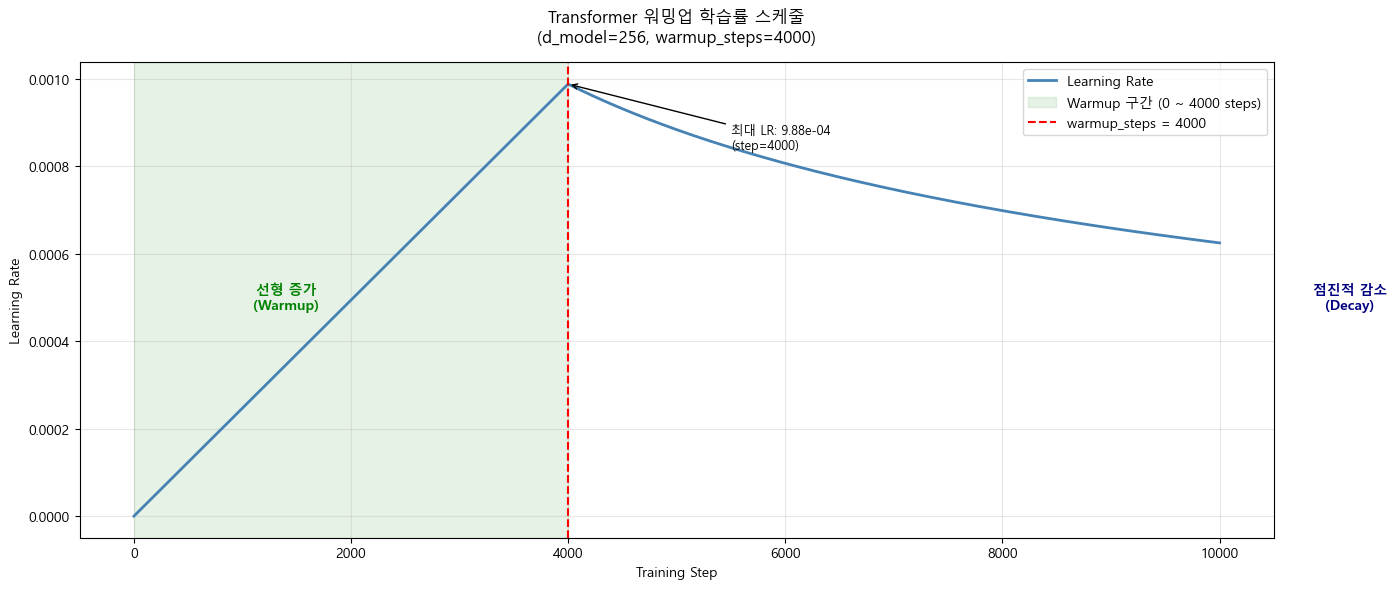

In [39]:
import matplotlib.pyplot as plt
import numpy as np

WARMUP_STEPS = 4000
D_MODEL_VIS  = 256   # 실제 모델 d_model과 동일

# 1 ~ 10000 step의 학습률 계산
steps = np.arange(1, 10001)
lrs = []
for step in steps:
    arg1 = step ** -0.5
    arg2 = step * (WARMUP_STEPS ** -1.5)
    lrs.append((D_MODEL_VIS ** -0.5) * min(arg1, arg2))

lrs = np.array(lrs)

fig, ax = plt.subplots(figsize=(14, 6))  # ← (12, 5) → (14, 6)

# LR 곡선 그리기
ax.plot(steps, lrs, color='steelblue', linewidth=2, label='Learning Rate')

# 워밍업 구간 음영 처리
ax.axvspan(0, WARMUP_STEPS, alpha=0.1, color='green',
           label=f'Warmup 구간 (0 ~ {WARMUP_STEPS} steps)')

# warmup_steps 수직선
ax.axvline(x=WARMUP_STEPS, color='red', linewidth=1.5,
           linestyle='--', label=f'warmup_steps = {WARMUP_STEPS}')

# 최대 LR 위치 화살표 표시 (위치 수정!)
max_idx = int(np.argmax(lrs))
ax.annotate(f'최대 LR: {lrs[max_idx]:.2e}\n(step={steps[max_idx]})',
            xy=(steps[max_idx], lrs[max_idx]),
            xytext=(steps[max_idx] + 1500, lrs[max_idx] * 0.85),  # ← 수정
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

# 구간 설명 텍스트
ax.text(WARMUP_STEPS * 0.35, lrs.max() * 0.48,
        '선형 증가\n(Warmup)', ha='center', fontsize=10,
        color='green', fontweight='bold')
ax.text(WARMUP_STEPS * 2.8, lrs.max() * 0.48,
        '점진적 감소\n(Decay)', ha='center', fontsize=10,
        color='navy', fontweight='bold')

ax.set_xlabel('Training Step')
ax.set_ylabel('Learning Rate')
ax.set_title(
    f'Transformer 워밍업 학습률 스케줄\n'
    f'(d_model={D_MODEL_VIS}, warmup_steps={WARMUP_STEPS})',
    fontsize=12, pad=15)  # ← pad 추가
ax.legend(fontsize=10, loc='upper right')  # ← loc 추가
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Loss Function (손실 함수)

**Cross Entropy Loss + Masking**

### 마스킹이 필요한 이유
- 패딩 토큰(0)은 학습에 영향을 주면 안 됨
- 마스크로 패딩 부분의 loss를 0으로 만듦

### 흐름
1. CrossEntropyLoss로 loss 계산
2. 패딩 위치 마스크 (`real != 0`)
3. 마스크 적용 (패딩은 0이 됨)
4. 마스킹되지 않은 입력 개수로 나누기 (평균화)

In [25]:
# reduction='none': loss를 토큰별로 계산 (스칼라 평균이 아닌 벡터) — 마스킹 적용을 위해 필요
loss_object = torch.nn.CrossEntropyLoss(reduction='none')

def loss_function(real, pred):
    # real != 0: 패딩(0)이 아닌 위치만 True — 실제 학습해야 할 토큰만 선택
    mask = (real != 0)
    loss_ = loss_object(pred, real)
    # Masking 되지 않은 입력의 개수로 Scaling하는 과정
    mask = mask.float()
    # 패딩 위치의 loss를 0으로 만듦 — 패딩은 학습에 영향 주면 안 됨
    loss_ *= mask
    # mask.sum(): 실제 토큰 개수로 나누어 평균화 (패딩 제외 평균)
    return loss_.sum() / mask.sum()

## Train Step 함수

학습 한 스텝을 정의합니다.

### 흐름
1. **Teacher Forcing**: `gold = tgt[:, 1:]` — 정답은 한 칸 뒤로
2. **마스크 생성**: 패딩 + Causality
3. **순전파(Forward)**: 모델 예측
4. **Loss 계산**: 예측 vs 정답
5. **역전파(Backward)**: gradient 계산
6. **파라미터 업데이트**: `optimizer.step()`

In [26]:
# Train Step 함수 정의
def train_step(src, tgt, model, optimizer):
    # ⭐ GPU로 이동
    src = src.to(device)
    tgt = tgt.to(device)
    
    # Teacher Forcing: gold = tgt[:, 1:] — 정답을 한 칸 뒤로 밀어 BOS 다음 토큰부터 예측
    # 예: tgt = [BOS, I, am, EOS] → gold = [I, am, EOS]
    gold = tgt[:, 1:]
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)
    
    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src, tgt, enc_mask, dec_enc_mask, dec_mask)
    
    # ⭐ CrossEntropyLoss를 위한 차원 조정
    # predictions: [batch, seq_len, vocab] → [batch, vocab, seq_len]
    # predictions[:, :-1]: 마지막 토큰 제외 — gold와 길이를 맞춤 (gold도 1개 짧음)
    # transpose(1, 2): CrossEntropyLoss가 [batch, vocab, seq] 형태를 요구함
    pred_for_loss = predictions[:, :-1].transpose(1, 2)
    loss = loss_function(gold, pred_for_loss)
    
    loss.backward()
    optimizer.step()
    
    return loss, enc_attns, dec_attns, dec_enc_attns

## Attention 시각화 함수

학습된 모델이 **어디에 주목하는지** 히트맵으로 보여주는 함수입니다.

### 시각화 종류
1. **Encoder Self-Attention** — 입력 문장 내 단어 관계
2. **Decoder Self-Attention** — 출력 문장 내 단어 관계
3. **Decoder-Encoder Attention (Cross)** — 입력과 출력 간 정렬

각 레이어, 각 헤드별로 다른 패턴이 나타납니다.

In [27]:
import matplotlib.pyplot as plt

# Attention 시각화 함수
def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    def draw(data, ax, x="auto", y="auto"):
        import seaborn
        # ⭐ GPU 텐서면 CPU로 옮기고 numpy 변환
        if hasattr(data, 'cpu'):
            data = data.cpu().detach().numpy()
        seaborn.heatmap(data,
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)
    
    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(4):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()
    
    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Decoder Self Layer", layer+1)
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()
        
        print("Decoder Src Layer", layer+1)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

## 번역 평가 함수 (Evaluate)

학습된 모델로 **실제 번역을 수행**하는 함수입니다.

### 흐름 (Greedy Decoding)
1. 입력 문장 전처리 + 토큰화
2. `<BOS>` 토큰으로 시작
3. 한 번에 한 단어씩 예측:
   - 현재까지의 출력으로 다음 단어 예측
   - 가장 확률 높은 단어 선택 (`argmax`)
   - 출력에 추가
4. `<EOS>` 토큰 만나면 종료
5. 최대 길이까지 도달해도 종료

### Greedy의 한계
- 한 번에 한 단어만 보니까 최적해는 아님
- 더 좋은 결과는 **Beam Search**로

In [28]:
# 번역 생성 함수 — Greedy Decoding 방식으로 한 토큰씩 순차 생성
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    sentence = preprocess_sentence(sentence)
    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)
    _input = torch.tensor(tokens).unsqueeze(0).to(device)
    
    ids = []
    # BOS 토큰으로 디코더 입력 시작 — 첫 번째 예측을 위한 시드(seed)
    output = torch.tensor([tgt_tokenizer.bos_id()]).unsqueeze(0).to(device)
    
    # model.eval(): Dropout 비활성화, BatchNorm 고정 등 평가 모드로 전환
    model.eval()  # 평가 모드
    # torch.no_grad(): 그래디언트 계산 중단 — 추론 시 불필요한 메모리 사용 방지
    with torch.no_grad():
        for i in range(dec_train.shape[-1]):
            enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(_input, output)
            predictions, enc_attns, dec_attns, dec_enc_attns = model(
                _input, output, enc_padding_mask, combined_mask, dec_padding_mask)
            # Greedy Decoding: 마지막 위치에서 가장 확률 높은 토큰 선택 (argmax)
            predicted_id = torch.argmax(torch.softmax(predictions, dim=-1)[0, -1]).item()
            
            # EOS 토큰이 나오면 번역 완료 — 생성 중단
            if tgt_tokenizer.eos_id() == predicted_id:
                result = tgt_tokenizer.decode_ids(ids)
                return pieces, result, enc_attns, dec_attns, dec_enc_attns
            
            # 선택된 토큰을 디코더 입력에 이어붙여 다음 토큰 예측에 사용
            ids.append(predicted_id)
            output = torch.cat([output, torch.tensor([[predicted_id]]).to(device)], dim=-1)
    
    result = tgt_tokenizer.decode_ids(ids)
    return pieces, result, enc_attns, dec_attns, dec_enc_attns

## 번역 실행 함수 (Translate)

`evaluate` 함수를 호출하고, 결과를 출력하는 wrapper 함수입니다.

### 사용 예시
```python
translate("안녕하세요", transformer, ko_tokenizer, en_tokenizer)
translate("오늘 날씨가 좋네요", transformer, ko_tokenizer, en_tokenizer, plot_attention=True)
```

`plot_attention=True`로 호출하면 어텐션 히트맵도 같이 보여줍니다.

In [29]:
# 번역 생성 및 Attention 시각화 결합
def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, result, enc_attns, dec_attns, dec_enc_attns = evaluate(
        sentence, model, src_tokenizer, tgt_tokenizer)
    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))
    if plot_attention:
        visualize_attention(pieces, result.split(), enc_attns, dec_attns, dec_enc_attns)

## 📊 Attention 시각화 — 어떤 입력 단어가 어떤 출력에 영향을 줬는지

학습된 모델의 어텐션 가중치를 히트맵으로 확인합니다.

| 시각화 | 설명 |
|---|---|
| Encoder Self-Attention | 입력 문장 내 단어들이 서로 얼마나 주목하는지 |
| Cross-Attention | 영어 단어를 생성할 때 한국어 입력의 어느 단어를 봤는지 |

- 색이 진할수록 해당 위치에 더 높은 어텐션 가중치가 할당됨
- 학습이 충분하다면 의미적으로 관련된 단어끼리 높은 값을 가져야 함
- 학습 초기에는 패턴이 고르게 분산될 수 있음 (랜덤에 가까움)

테스트 문장: 어서오세요


C:\Users\yoehe\AppData\Local\Temp\ipykernel_10528\176762796.py:43: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\yoehe\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


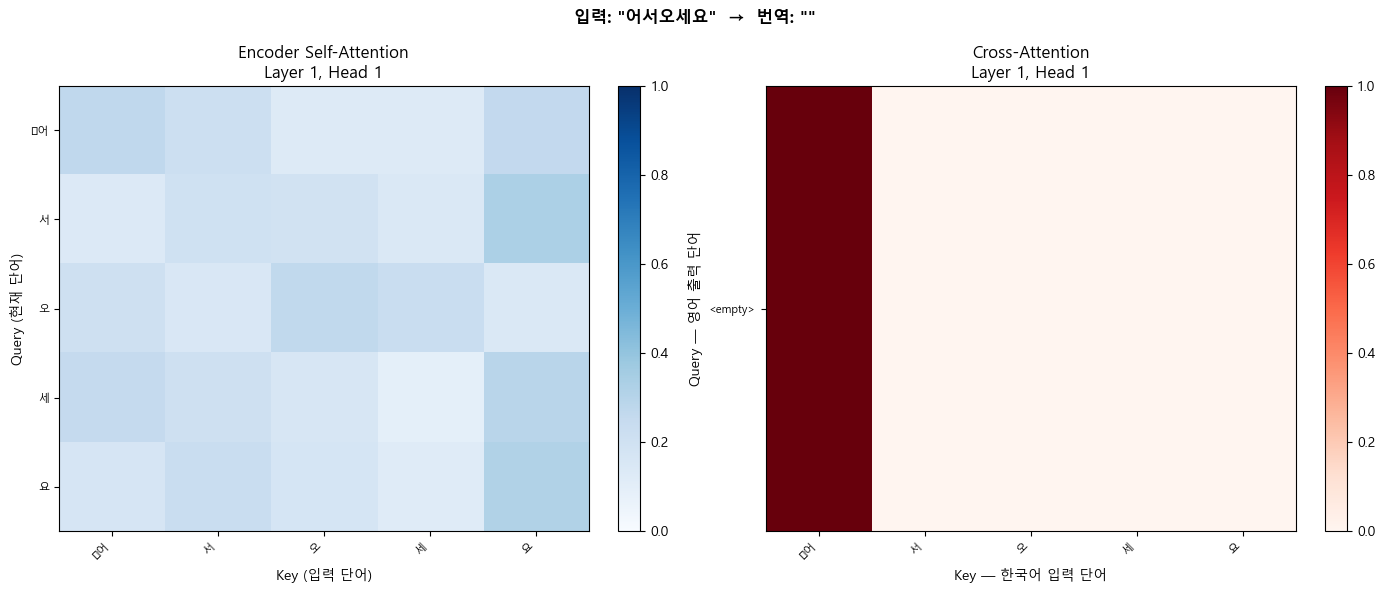

번역 결과:   


In [32]:
import matplotlib.pyplot as plt

def plot_attention_maps(sentence, model, src_tok, tgt_tok, layer=0, head=0):
    """Encoder Self-Attention + Cross-Attention을 matplotlib imshow로 시각화"""
    # 번역 실행 및 어텐션 가중치 수집
    pieces, result, enc_attns, dec_attns, dec_enc_attns = evaluate(
        sentence, model, src_tok, tgt_tok)

    tgt_pieces = result.split() if result else ['<empty>']

    # 어텐션 가중치 추출 및 CPU numpy 변환
    enc_attn   = enc_attns[layer][0, head,
                     :len(pieces), :len(pieces)].cpu().detach().numpy()
    cross_attn = dec_enc_attns[layer][0, head,
                     :len(tgt_pieces), :len(pieces)].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # [왼쪽] Encoder Self-Attention
    im1 = axes[0].imshow(enc_attn, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    axes[0].set_xticks(range(len(pieces)))
    axes[0].set_xticklabels(pieces, rotation=45, ha='right', fontsize=8)
    axes[0].set_yticks(range(len(pieces)))
    axes[0].set_yticklabels(pieces, fontsize=8)
    axes[0].set_xlabel('Key (입력 단어)')
    axes[0].set_ylabel('Query (현재 단어)')
    axes[0].set_title(f'Encoder Self-Attention\nLayer {layer+1}, Head {head+1}')
    plt.colorbar(im1, ax=axes[0], fraction=0.046)

    # [오른쪽] Decoder-Encoder Cross-Attention
    im2 = axes[1].imshow(cross_attn, cmap='Reds', aspect='auto', vmin=0, vmax=1)
    axes[1].set_xticks(range(len(pieces)))
    axes[1].set_xticklabels(pieces, rotation=45, ha='right', fontsize=8)
    axes[1].set_yticks(range(len(tgt_pieces)))
    axes[1].set_yticklabels(tgt_pieces, fontsize=8)
    axes[1].set_xlabel('Key — 한국어 입력 단어')
    axes[1].set_ylabel('Query — 영어 출력 단어')
    axes[1].set_title(f'Cross-Attention\nLayer {layer+1}, Head {head+1}')
    plt.colorbar(im2, ax=axes[1], fraction=0.046)

    plt.suptitle(f'입력: "{sentence}"  →  번역: "{result}"',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return result

# 번역 + 어텐션 시각화 실행 (학습 후 실행)
test_sentence = "어서오세요"
print(f"테스트 문장: {test_sentence}")
result = plot_attention_maps(
    test_sentence, transformer, ko_tokenizer, en_tokenizer, layer=0, head=0)
print(f"번역 결과:   {result}")

In [34]:
import time

WORK_DIR = r"C:\AI_study\Transforme"
EPOCHS = 5
BATCH_SIZE = 16   # 메모리 부족하면 8로 줄이기

# 에포크별 loss 기록 (시각화용)
epoch_losses = []

transformer.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    num_batches = 0
    
    for batch_idx in range(0, len(enc_train), BATCH_SIZE):
        src = enc_train[batch_idx:batch_idx+BATCH_SIZE]
        tgt = dec_train[batch_idx:batch_idx+BATCH_SIZE]
        
        try:
            loss, *_ = train_step(src, tgt, transformer, optimizer)
            learning_rate.step()
            epoch_loss += loss.item()
            num_batches += 1
            
            if num_batches % 100 == 0:
                print(f"  Batch {num_batches}, Loss: {loss.item():.4f}")
        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"⚠️ 메모리 부족! batch_idx={batch_idx}")
                torch.cuda.empty_cache()
                continue
            raise e
    
    avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
    epoch_losses.append(avg_loss)  # 시각화를 위해 에포크별 loss 저장
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")
    
    # 체크포인트 저장
    checkpoint_path = os.path.join(WORK_DIR, f"checkpoint_epoch_{epoch+1}.pt")
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': transformer.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
    }, checkpoint_path)
    print(f"💾 저장: {checkpoint_path}")

  Batch 100, Loss: 107.9784
  Batch 200, Loss: 106.7824
  Batch 300, Loss: 95.2798
  Batch 400, Loss: 94.3307
  Batch 500, Loss: 92.5514
  Batch 600, Loss: 92.1100
  Batch 700, Loss: 86.9441
  Batch 800, Loss: 81.7000
  Batch 900, Loss: 78.4705
  Batch 1000, Loss: 79.2879
  Batch 1100, Loss: 72.6834
  Batch 1200, Loss: 69.4041
  Batch 1300, Loss: 67.2249
  Batch 1400, Loss: 72.1915
  Batch 1500, Loss: 67.7529
  Batch 1600, Loss: 64.0009
  Batch 1700, Loss: 64.1135
  Batch 1800, Loss: 60.7273
  Batch 1900, Loss: 61.5424
  Batch 2000, Loss: 57.9532
  Batch 2100, Loss: 57.3795
  Batch 2200, Loss: 54.9804
  Batch 2300, Loss: 62.5949
  Batch 2400, Loss: 53.7229
  Batch 2500, Loss: 52.1390
  Batch 2600, Loss: 53.0373
  Batch 2700, Loss: 53.9786
  Batch 2800, Loss: 47.9338
  Batch 2900, Loss: 45.3207
  Batch 3000, Loss: 45.4740
  Batch 3100, Loss: 47.0786
  Batch 3200, Loss: 47.8777
  Batch 3300, Loss: 44.9553
  Batch 3400, Loss: 46.3734
  Batch 3500, Loss: 43.8368
  Batch 3600, Loss: 41.7778

## 📊 학습 Loss 곡선 — 학습이 진행됐다는 증거

에포크가 지날수록 **Loss가 감소**하는 패턴을 확인합니다.

- Loss 감소 → 모델이 데이터 패턴을 점점 학습하고 있음
- 초반 급격한 감소 후 완만해지는 패턴이 정상적
- 감소가 멈추거나 증가한다면 과적합(Overfitting) 또는 학습률 문제 신호
- 더 긴 학습(더 많은 에포크)이 필요한지 판단 기준으로 활용

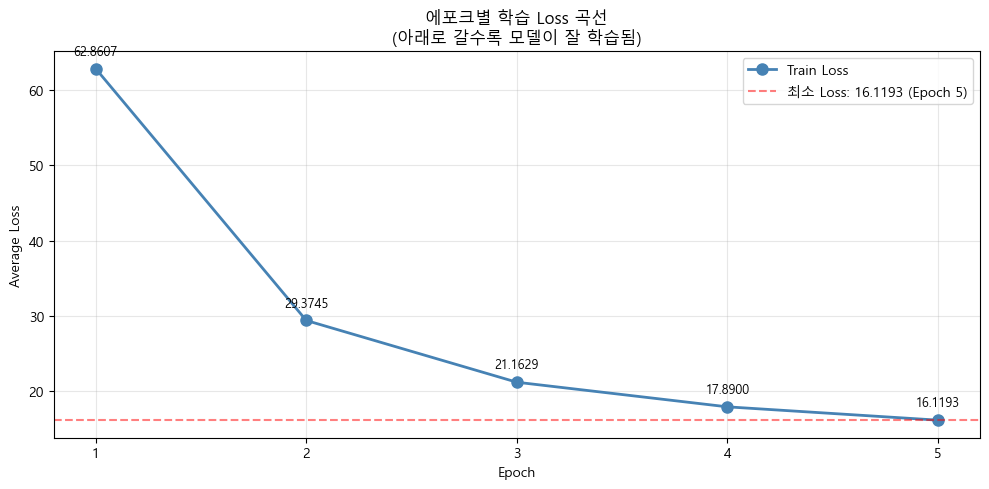

초기 Loss: 62.8607
최종 Loss: 16.1193
총 감소량: 46.7414 (74.4% 감소)


In [35]:
import matplotlib.pyplot as plt

# epoch_losses는 학습 루프에서 자동 기록됨
if 'epoch_losses' in dir() and len(epoch_losses) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))

    epochs_x = range(1, len(epoch_losses) + 1)

    # Loss 곡선
    ax.plot(epochs_x, epoch_losses, 'o-', color='steelblue',
            linewidth=2, markersize=8, label='Train Loss')

    # 최솟값 수평선 표시
    min_loss = min(epoch_losses)
    min_ep   = epoch_losses.index(min_loss) + 1
    ax.axhline(y=min_loss, color='red', linestyle='--', alpha=0.5,
               label=f'최소 Loss: {min_loss:.4f} (Epoch {min_ep})')

    # 각 포인트에 loss 값 표시
    for i, loss in enumerate(epoch_losses):
        ax.annotate(f'{loss:.4f}', (i + 1, loss),
                    textcoords='offset points', xytext=(0, 10),
                    fontsize=9, ha='center')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Average Loss')
    ax.set_title('에포크별 학습 Loss 곡선\n(아래로 갈수록 모델이 잘 학습됨)', fontsize=12)
    ax.set_xticks(list(epochs_x))
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 학습 효과 요약
    print(f"초기 Loss: {epoch_losses[0]:.4f}")
    print(f"최종 Loss: {epoch_losses[-1]:.4f}")
    reduction = (1 - epoch_losses[-1] / epoch_losses[0]) * 100
    print(f"총 감소량: {epoch_losses[0] - epoch_losses[-1]:.4f} ({reduction:.1f}% 감소)")
else:
    print("epoch_losses 데이터가 없습니다. 학습 루프를 먼저 실행하세요.")

In [36]:
# 학습이 끝난 후 번역 테스트
translate("안녕하세요", transformer, ko_tokenizer, en_tokenizer)
translate("오늘 날씨가 좋네요", transformer, ko_tokenizer, en_tokenizer)
translate("저는 인공지능을 공부하고 있습니다", transformer, ko_tokenizer, en_tokenizer)

Input: 안녕하세요
Predicted translation: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Input: 오늘 날씨가 좋네요
Predicted translation: the year the year the second the second the second the second the second the second the second the second the second the second the second the second the second the second the second the the the the the the the the the the the the the the the the
Input: 저는 인공지능을 공부하고 있습니다
Predicted translation: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the


## Gradio로 번역 창 만들기

In [40]:
import gradio as gr

def gradio_translate(text):
    pieces, result, *_ = evaluate(text, transformer, ko_tokenizer, en_tokenizer)
    return result

demo = gr.Interface(
    fn=gradio_translate,
    inputs=gr.Textbox(label="한국어"),
    outputs=gr.Textbox(label="영어"),
    title="🌐 트랜스포머 번역기"
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://58e394a10789d82c7c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 여기서 번역해보니 그냥 엉망임 ;;;;;;
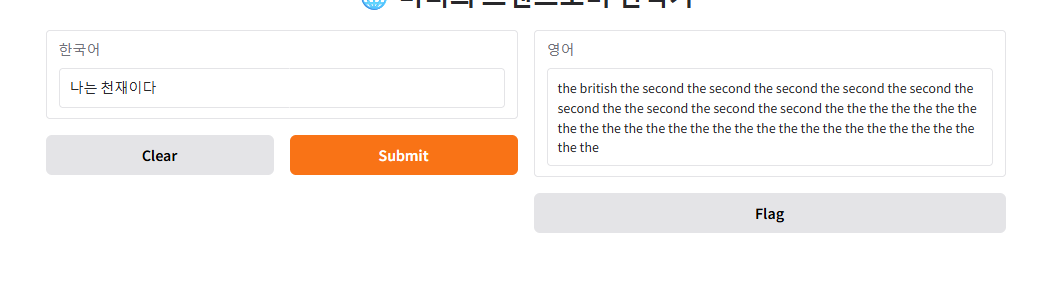
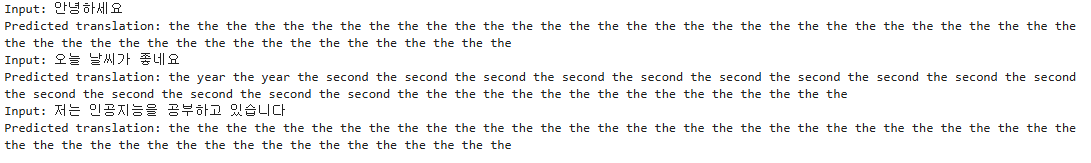

# 📝 프로젝트 회고록

> 트랜스포머 번역기 만들기 회고
>
> **환경:** 로컬 환경 (Windows + Jupyter Notebook)

---

## 🎯 프로젝트 목표

트랜스포머를 직접 PyTorch로 만들어보고, 한국어를 영어로 번역하는 모델을 학습시켜 보는 것.

번역 품질을 완벽하게 만드는 것보다 **트랜스포머가 어떻게 작동하는지 이해하는 것**이 목표였다.

---

## ✅ 무엇을 했나

### 데이터 준비
- Korean-English Park 데이터셋 다운로드
- 중복 제거 (약 78,000개 문장 쌍)
- SentencePiece로 토크나이저 학습
- 토큰 길이 50 이하 문장만 필터링

### 모델 만들기
- Positional Encoding
- Multi-Head Attention
- Position-wise FFN
- Encoder Layer / Decoder Layer
- 마스크 생성 함수
- 전체 Transformer 모델

### 학습 & 결과 확인
- 5 epoch 학습
- Loss 62.86 → 16.12 (74% 감소)
- Gradio로 번역

### 느낀점
- 데이터량과 로컬의 한계로 번역이 제대로 안되어서 아쉬웠습니다
- 기본적인 개념을 이해하는데는 시간이 걸리겠지만 많은 것을 배웠습니다